# DS317.R11 - Kiểm chứng nhanh PA1 (Văn Quyền)

**Phạm vi (chỉ công việc của Nguyễn Văn Quyền trong bảng phân công):**
1. Thay tên cột giả định bằng tên cột thật trong Biến mục tiêu / Đầu vào; ghi rõ quy tắc đơn hủy/trả.
2. Kiểm tra dữ liệu có bảng khuyến mãi lên lịch trước (promotions.csv) không.
3. Kiểm chứng nhanh PA1 (bảng 4.1): tạo chuỗi tuần cho 4 danh mục, đếm số mẫu, chạy baseline
   seasonal-naive và trung bình 4 tuần (WMAPE, MAE, thời gian chạy) + biểu đồ minh họa.

Kết quả: `artifacts/vanquyen/pa1_validation_evidence.json` và 4 biểu đồ PNG - dùng làm bằng chứng
khi điền vào bảng 4.1 và sửa Phần 3 của bản đề xuất.

## 0. Nhập thư viện và cấu hình

In [1]:
import json, time, hashlib, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Image, display

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "engine" else os.getcwd()
DS = os.path.join(ROOT, "dataset")
OUT_DIR = os.path.join(ROOT, "artifacts", "vanquyen")
OUT = os.path.join(OUT_DIR, "pa1_validation_evidence.json")
os.makedirs(OUT_DIR, exist_ok=True)

T0 = time.perf_counter()
ev = {}


def sha(p, n=1 << 20):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(n), b""):
            h.update(b)
    return h.hexdigest()[:16]


BANG = ["order_items", "orders", "products", "promotions", "sales", "web_traffic", "inventory", "returns"]
ev["thong_tin_chung"] = {
    "nguoi_thuc_hien": "Nguyễn Văn Quyền",
    "pham_vi": "Phần 3 (phát biểu bài toán) + Phần 4.1 kiểm chứng nhanh PA1",
    "thoi_diem_chay": pd.Timestamp.now().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "file_da_dung": {t: {"sha256_16": sha(os.path.join(DS, t + ".csv")),
                         "dung_luong_byte": os.path.getsize(os.path.join(DS, t + ".csv"))} for t in BANG},
}

## 1. Tên cột thật

In [2]:
oi = pd.read_csv(os.path.join(DS, "order_items.csv"))
orders = pd.read_csv(os.path.join(DS, "orders.csv"), parse_dates=["order_date"])
prod = pd.read_csv(os.path.join(DS, "products.csv"))
promo = pd.read_csv(os.path.join(DS, "promotions.csv"), parse_dates=["start_date", "end_date"])
traffic = pd.read_csv(os.path.join(DS, "web_traffic.csv"), parse_dates=["date"])
inv = pd.read_csv(os.path.join(DS, "inventory.csv"), parse_dates=["snapshot_date"])
rets = pd.read_csv(os.path.join(DS, "returns.csv"), parse_dates=["return_date"])

ev["viec_1_ten_cot_that"] = {
    "ghi_chu": "Thay tên cột giả định trong bản đề xuất bằng tên cột thật trong file CSV.",
    "cau_truc_thuc_te": {t: list(df.columns) for t, df in
                         [("order_items", oi), ("orders", orders), ("products", prod),
                          ("promotions", promo), ("web_traffic", traffic), ("inventory", inv),
                          ("returns", rets)]},
    "sua_ten_cot": [
        {"trong_de_xuat": "discount", "ten_that": "order_items.discount_amount"},
        {"trong_de_xuat": "unit_price", "ten_that": "order_items.unit_price", "trang_thai": "đúng, giữ nguyên"},
        {"trong_de_xuat": "quantity", "ten_that": "order_items.quantity", "trang_thai": "đúng, giữ nguyên"},
        {"trong_de_xuat": "order_date",
         "ten_that": "orders.order_date (KHÔNG nằm trong order_items, phải nối qua order_id)"},
        {"trong_de_xuat": "category", "ten_that": "products.category (nối qua product_id)"},
        {"trong_de_xuat": "traffic",
         "ten_that": "web_traffic.date + sessions / unique_visitors / page_views / bounce_rate"},
        {"trong_de_xuat": "tồn kho snapshot",
         "ten_that": "inventory.snapshot_date + stock_on_hand / fill_rate / days_of_supply / stockout_flag"},
        {"trong_de_xuat": "phí ship",
         "ten_that": "shipments.shipping_fee - KHÔNG có trong order_items nên biến mục tiêu vốn đã không gồm phí ship"},
    ],
    "cong_thuc_bien_muc_tieu": (
        "revenue_net(danh_mục, tuần) = TỔNG(order_items.quantity * order_items.unit_price "
        "- order_items.discount_amount) trên các dòng có orders.order_date thuộc tuần đó "
        "và products.category = danh_mục, loại bỏ orders.order_status == 'cancelled'."
    ),
}

C:\Users\Admin\AppData\Local\Temp\ipykernel_24124\1205493290.py:1: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  oi = pd.read_csv(os.path.join(DS, "order_items.csv"))


## 1b. quy tắc đơn hủy / trả

In [3]:
st = orders["order_status"].value_counts()
oi_line = oi.copy()
oi_line["doanh_thu_dong"] = oi_line["quantity"] * oi_line["unit_price"] - oi_line["discount_amount"]
m = oi_line.merge(orders[["order_id", "order_date", "order_status"]], on="order_id", how="inner")
m = m.merge(prod[["product_id", "category"]], on="product_id", how="inner")

rev_by_status = m.groupby("order_status")["doanh_thu_dong"].agg(["sum", "count"])
total_rev = float(m["doanh_thu_dong"].sum())
ret_orders = set(rets["order_id"])

ev["viec_1_quy_tac_don_huy_tra"] = {
    "cac_trang_thai_don_trong_du_lieu": {k: int(v) for k, v in st.items()},
    "doanh_thu_theo_trang_thai": {k: {"doanh_thu": float(r["sum"]), "so_dong": int(r["count"]),
                                      "ty_trong_phan_tram": round(float(r["sum"]) / total_rev * 100, 3)}
                                  for k, r in rev_by_status.iterrows()},
    "bang_returns": {
        "so_dong": int(len(rets)),
        "so_don_bi_tra": int(len(ret_orders)),
        "tong_tien_hoan": float(rets["refund_amount"].sum()),
        "khoang_ngay_tra": [str(rets["return_date"].min().date()), str(rets["return_date"].max().date())],
    },
    "quy_tac_chot": (
        "LOẠI đơn có order_status == 'cancelled' khỏi biến mục tiêu, vì đơn hủy không phát sinh "
        "doanh thu và không tiêu tốn hàng nhập. GIỮ đơn 'returned': tại mốc cắt đầu tuần, việc trả hàng "
        "chưa xảy ra nên không biết trước - loại trừ sẽ gây rò rỉ thông tin tương lai (look-ahead). "
        "GIỮ 'created'/'paid'/'shipped'/'delivered'. Cột refund_amount trong returns.csv chỉ dùng để "
        "báo cáo, KHÔNG trừ vào nhãn."
    ),
    "anh_huong_cua_quy_tac": {
        "doanh_thu_giu_tat_ca": total_rev,
        "doanh_thu_loai_cancelled": float(m.loc[m.order_status != "cancelled", "doanh_thu_dong"].sum()),
        "doanh_thu_loai_cancelled_va_returned": float(
            m.loc[~m.order_status.isin(["cancelled", "returned"]), "doanh_thu_dong"].sum()),
        "chenh_lech_phan_tram_khi_loai_cancelled": round(
            (float(m.loc[m.order_status != "cancelled", "doanh_thu_dong"].sum()) / total_rev - 1) * 100, 3),
    },
}

## 2. bảng khuyến mãi lên lịch trước?

In [4]:
promo_ok = promo.dropna(subset=["start_date", "end_date"])
lead = (promo_ok["end_date"] - promo_ok["start_date"]).dt.days
ev["viec_2_bang_khuyen_mai"] = {
    "ket_luan": "CÓ - promotions.csv là bảng khuyến mãi lên lịch trước, có start_date/end_date/discount_value.",
    "so_dong": int(len(promo)),
    "cac_cot": list(promo.columns),
    "khoang_thoi_gian": [str(promo_ok["start_date"].min().date()), str(promo_ok["end_date"].max().date())],
    "do_dai_chien_dich_ngay": {"nho_nhat": int(lead.min()), "trung_vi": float(lead.median()), "lon_nhat": int(lead.max())},
    "loai_khuyen_mai": {str(k): int(v) for k, v in promo["promo_type"].value_counts(dropna=False).items()},
    "danh_muc_ap_dung": {str(k): int(v) for k, v in promo["applicable_category"].value_counts(dropna=False).items()},
    "ty_le_thieu_danh_muc_ap_dung_phan_tram": round(float(promo["applicable_category"].isna().mean()) * 100, 2),
    "lien_ket_voi_order_items": {
        "cot_khoa": ["order_items.promo_id", "order_items.promo_id_2"],
        "ty_le_dong_co_promo_id_phan_tram": round(float(oi["promo_id"].notna().mean()) * 100, 2),
        "ty_le_dong_co_promo_id_2_phan_tram": round(float(oi["promo_id_2"].notna().mean()) * 100, 2),
        "so_promo_id_khop_bang_promotions": int(oi["promo_id"].dropna().isin(promo["promo_id"]).sum()),
    },
    "sua_o_muc_dau_vao": (
        "Đặc trưng chiết khấu KẾ HOẠCH là hợp lệ và biết trước: lấy từ promotions.csv "
        "(số chiến dịch đang chạy trong tuần t+h, tổng discount_value, có khuyến mãi theo danh mục) "
        "vì start_date/end_date đã biết từ trước mốc cắt. "
        "Riêng order_items.discount_amount là chiết khấu THỰC TẾ -> chỉ được dùng bản trễ (lag)."
    ),
}

## 3. chuỗi tuần 4 danh mục

In [5]:
panel = m.loc[m["order_status"] != "cancelled"].copy()
panel["tuan"] = panel["order_date"] - pd.to_timedelta(panel["order_date"].dt.weekday, unit="D")
wk = panel.groupby(["category", "tuan"])["doanh_thu_dong"].sum().rename("doanh_thu").reset_index()

danh_sach_tuan = pd.date_range(wk["tuan"].min(), wk["tuan"].max(), freq="W-MON")
danh_muc = sorted(prod["category"].unique())
grid = pd.MultiIndex.from_product([danh_muc, danh_sach_tuan], names=["category", "tuan"]).to_frame(index=False)
wk = grid.merge(wk, on=["category", "tuan"], how="left")
wk["doanh_thu"] = wk["doanh_thu"].fillna(0.0)

first_day, last_day = panel["order_date"].min(), panel["order_date"].max()
wk = wk[(wk["tuan"] >= first_day) & (wk["tuan"] + pd.Timedelta(days=6) <= last_day)]

pivot = wk.pivot(index="tuan", columns="category", values="doanh_thu").sort_index()

MOC_TRAIN, NAM_VAL, NAM_TEST = pd.Timestamp("2020-12-31"), 2021, 2022
idx = pivot.index
split = np.where(idx <= MOC_TRAIN, "train", np.where(idx.year == NAM_VAL, "validation", "test"))

ev["viec_3_chuoi_tuan"] = {
    "dinh_nghia_tuan": "Thứ 2 -> Chủ nhật, nhãn theo ngày Thứ 2; mốc cắt = cuối ngày Chủ nhật.",
    "khoang_tuan": [str(idx.min().date()), str(idx.max().date())],
    "so_tuan": int(len(idx)),
    "so_danh_muc": len(danh_muc),
    "danh_muc": danh_muc,
    "so_mau_tong": int(len(idx) * len(danh_muc)),
    "chia_du_lieu": {
        "quy_tac": "train <= 2020-12-31, validation = năm 2021, test = năm 2022 (chia theo thời gian, không xáo trộn)",
        "train": {"so_tuan": int((split == "train").sum()),
                  "tu_ngay": str(idx[split == "train"].min().date()), "den_ngay": str(idx[split == "train"].max().date()),
                  "so_mau": int((split == "train").sum() * len(danh_muc))},
        "validation": {"so_tuan": int((split == "validation").sum()),
                       "tu_ngay": str(idx[split == "validation"].min().date()),
                       "den_ngay": str(idx[split == "validation"].max().date()),
                       "so_mau": int((split == "validation").sum() * len(danh_muc))},
        "test": {"so_tuan": int((split == "test").sum()),
                 "tu_ngay": str(idx[split == "test"].min().date()), "den_ngay": str(idx[split == "test"].max().date()),
                 "so_mau": int((split == "test").sum() * len(danh_muc))},
    },
    "thong_ke_theo_danh_muc": {
        c: {
            "doanh_thu_tuan_trung_binh": float(pivot[c].mean()),
            "doanh_thu_tuan_trung_vi": float(pivot[c].median()),
            "do_lech_chuan": float(pivot[c].std()),
            "nho_nhat": float(pivot[c].min()), "lon_nhat": float(pivot[c].max()),
            "do_lech_skewness": float(pivot[c].skew()),
            "so_tuan_bang_0": int((pivot[c] == 0).sum()),
            "ty_le_tuan_bang_0_phan_tram": round(float((pivot[c] == 0).mean()) * 100, 3),
            "ty_trong_doanh_thu_phan_tram": round(float(pivot[c].sum() / pivot.values.sum()) * 100, 2),
        } for c in danh_muc},
}

## 4. baseline

In [6]:
def wmape(y, yh):
    d = np.abs(y).sum()
    return float(np.abs(y - yh).sum() / d) if d > 0 else float("nan")


def chay_baseline(cac_nam_danh_gia):
    """Rolling origin: mỗi tuần t trong lịch sử làm mốc cắt -> dự báo t+1..t+4."""
    rows = []
    vals = pivot.values
    n = len(pivot)
    for ti in range(n):
        for h in range(1, 5):
            tgt = ti + h
            if tgt >= n or idx[tgt].year not in cac_nam_danh_gia:
                continue
            for ci, c in enumerate(danh_muc):
                y = vals[tgt, ci]
                sn = vals[tgt - 52, ci] if tgt - 52 >= 0 else np.nan          # seasonal-naive lag 52 tuần
                ma = vals[ti - 3:ti + 1, ci].mean() if ti - 3 >= 0 else np.nan  # trung bình 4 tuần trước mốc cắt
                rows.append((c, h, y, sn, ma))
    return pd.DataFrame(rows, columns=["category", "h", "y_that", "seasonal_naive", "trung_binh_4_tuan"]).dropna()


t_b0 = time.perf_counter()
bt = chay_baseline({NAM_VAL})
t_baseline = time.perf_counter() - t_b0


def cham_diem(df):
    return {
        "so_mau": int(len(df)),
        "seasonal_naive": {"WMAPE": round(wmape(df.y_that.values, df.seasonal_naive.values), 4),
                           "MAE": round(float(np.abs(df.y_that - df.seasonal_naive).mean()), 2)},
        "trung_binh_4_tuan": {"WMAPE": round(wmape(df.y_that.values, df.trung_binh_4_tuan.values), 4),
                              "MAE": round(float(np.abs(df.y_that - df.trung_binh_4_tuan).mean()), 2)},
    }


ev["viec_3_baseline_validation_2021"] = {
    "thiet_ke": "Rolling origin: mỗi tuần t trong lịch sử làm mốc cắt, dự báo h = 1..4 tuần; "
                "chỉ chấm điểm các tuần mục tiêu rơi vào năm 2021.",
    "do_do": "WMAPE = tổng|thật - dự báo| / tổng|thật| (chính), MAE (phụ).",
    "baseline_1_seasonal_naive": "dự báo(t+h) = doanh thu(t+h-52) - cùng kỳ năm trước.",
    "baseline_2_trung_binh_4_tuan": "dự báo(t+h) = trung bình 4 tuần gần nhất trước mốc cắt t.",
    "tong_the": cham_diem(bt),
    "theo_danh_muc": {c: cham_diem(g) for c, g in bt.groupby("category")},
    "theo_horizon": {"h%d" % h: cham_diem(g) for h, g in bt.groupby("h")},
    "thoi_gian_chay_baseline_giay": round(t_baseline, 3),
}

bt22 = chay_baseline({NAM_TEST})
ev["viec_3_baseline_test_2022_tham_khao"] = {
    "canh_bao": "Chỉ để tham khảo. Việc chọn mô hình phải dựa trên validation 2021.",
    "tong_the": cham_diem(bt22),
    "theo_danh_muc": {c: cham_diem(g) for c, g in bt22.groupby("category")},
}

ev["ket_luan_PA1"] = {
    "du_lieu": "ĐẠT - nhãn tạo được từ order_items + orders + products; số mẫu = %d (tuần x danh mục)."
               % (len(idx) * len(danh_muc)),
    "ky_thuat": "ĐẠT - baseline chạy %.2f giây, cả pipeline %.1f giây, rất xa ngưỡng 10 phút trên Colab."
                % (t_baseline, time.perf_counter() - T0),
    "rui_ro": "Casual và GenZ tỷ trọng doanh thu nhỏ -> WMAPE cao hơn, xem mục theo_danh_muc.",
}
ev["thong_tin_chung"]["tong_thoi_gian_chay_giay"] = round(time.perf_counter() - T0, 2)

with open(OUT, "w", encoding="utf-8") as f:
    json.dump(ev, f, ensure_ascii=False, indent=2)

## 5. Biểu đồ minh họa

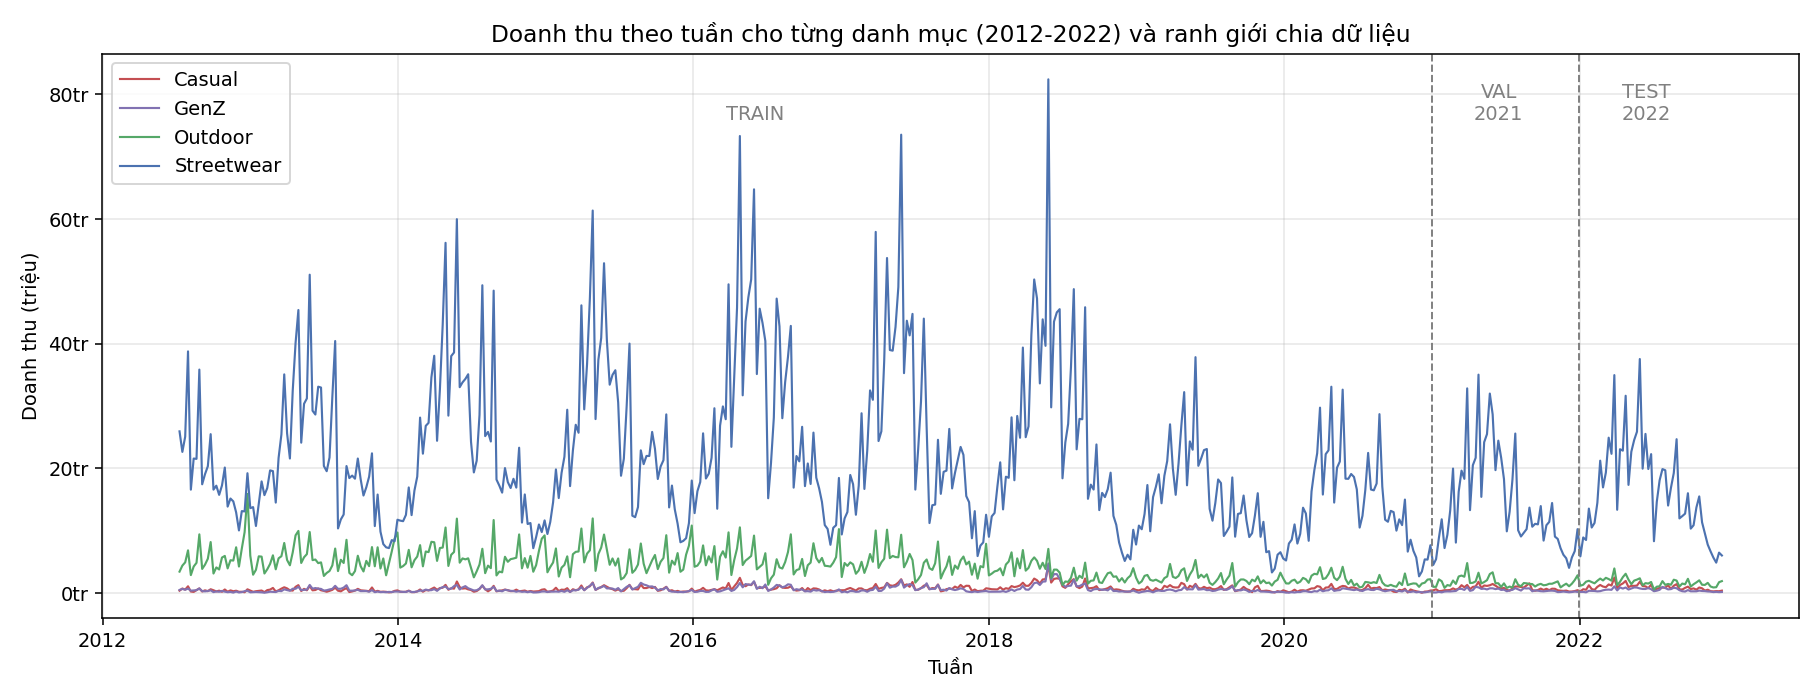

C:\Users\Admin\AppData\Local\Temp\ipykernel_24124\1792293.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


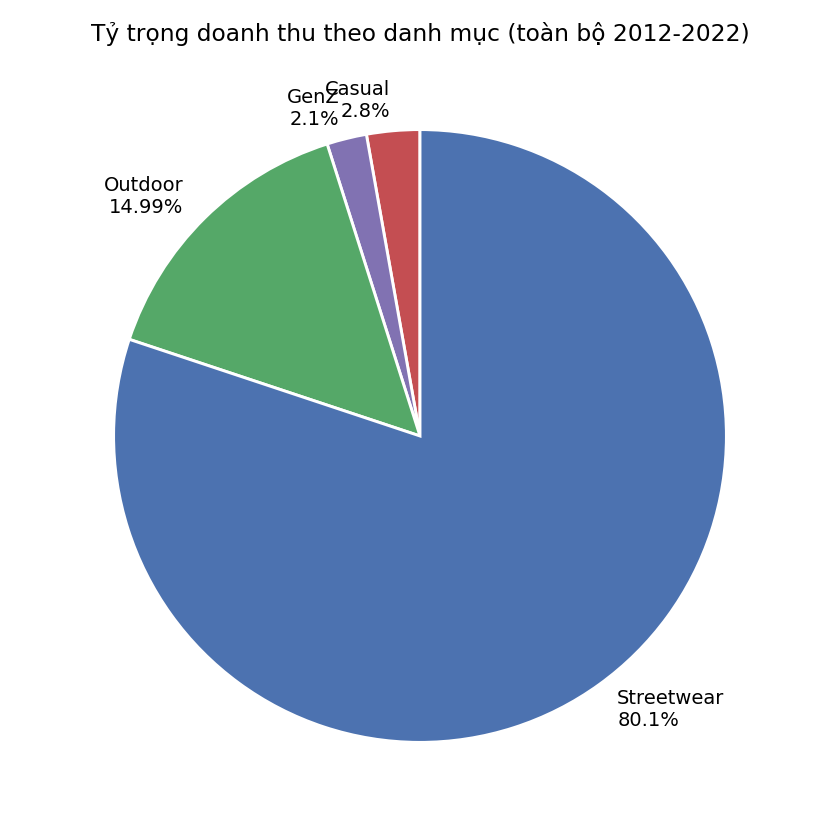

C:\Users\Admin\AppData\Local\Temp\ipykernel_24124\1792293.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


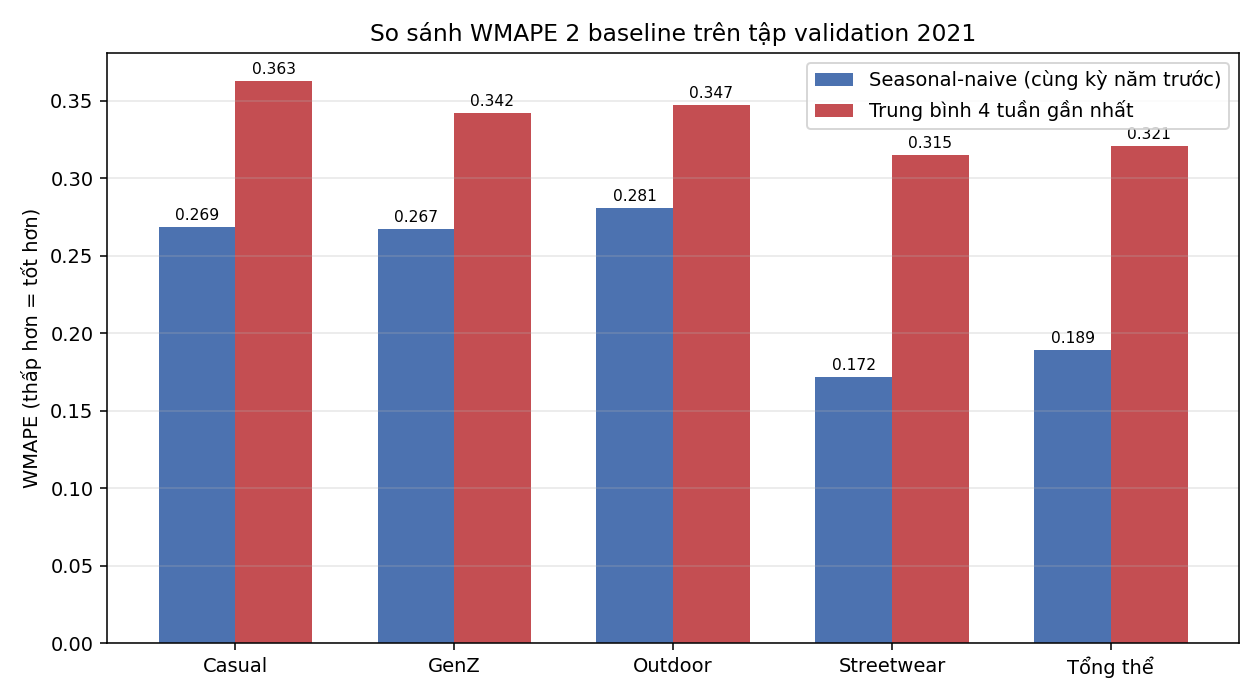

C:\Users\Admin\AppData\Local\Temp\ipykernel_24124\1792293.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


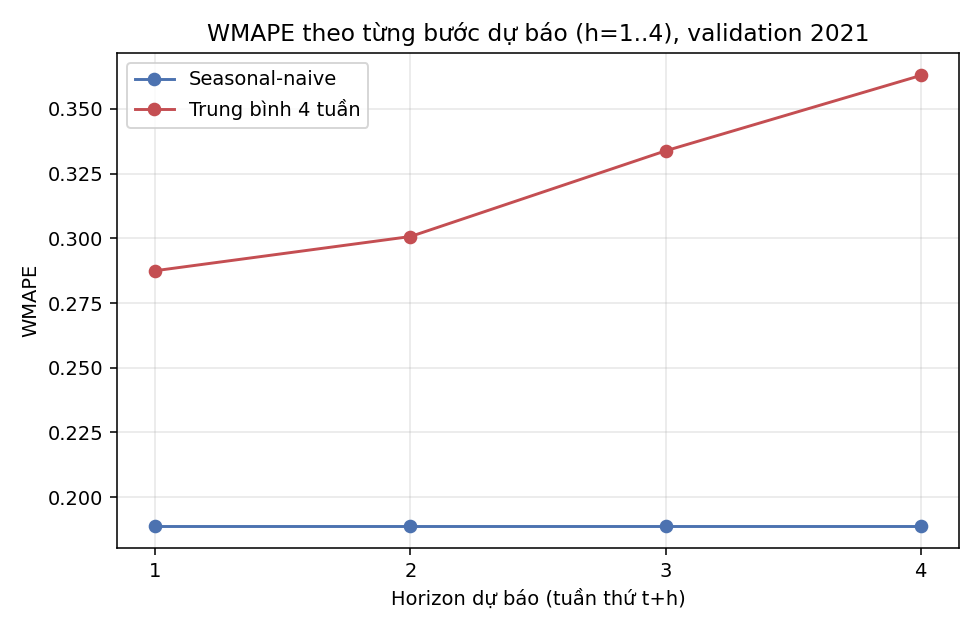

ĐÃ GHI: D:\datathon-2026-sales-forecasting\artifacts\vanquyen\pa1_validation_evidence.json
ĐÃ VẼ 4 biểu đồ trong D:\datathon-2026-sales-forecasting\artifacts\vanquyen
{
  "quy_tac": "train <= 2020-12-31, validation = năm 2021, test = năm 2022 (chia theo thời gian, không xáo trộn)",
  "train": {
    "so_tuan": 443,
    "tu_ngay": "2012-07-09",
    "den_ngay": "2020-12-28",
    "so_mau": 1772
  },
  "validation": {
    "so_tuan": 52,
    "tu_ngay": "2021-01-04",
    "den_ngay": "2021-12-27",
    "so_mau": 208
  },
  "test": {
    "so_tuan": 51,
    "tu_ngay": "2022-01-03",
    "den_ngay": "2022-12-19",
    "so_mau": 204
  }
}
{
  "so_mau": 832,
  "seasonal_naive": {
    "WMAPE": 0.189,
    "MAE": 819889.26
  },
  "trung_binh_4_tuan": {
    "WMAPE": 0.3212,
    "MAE": 1393087.76
  }
}


C:\Users\Admin\AppData\Local\Temp\ipykernel_24124\1792293.py:70: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
mau_danh_muc = {"Streetwear": "#4C72B0", "Outdoor": "#55A868", "Casual": "#C44E52", "GenZ": "#8172B2"}

def dinh_dang_trieu(x, pos):
    return f"{x/1e6:,.0f}tr"

# Biểu đồ 1: chuỗi doanh thu tuần theo danh mục (2012-2022), có đánh dấu train/val/test
fig, ax = plt.subplots(figsize=(13, 5))
for c in danh_muc:
    ax.plot(pivot.index, pivot[c], label=c, color=mau_danh_muc.get(c), linewidth=1.1)
ax.axvline(MOC_TRAIN, color="gray", linestyle="--", linewidth=1)
ax.axvline(pd.Timestamp("2021-12-31"), color="gray", linestyle="--", linewidth=1)
ax.text(pd.Timestamp("2016-06-01"), pivot.values.max()*0.92, "TRAIN", ha="center", color="gray")
ax.text(pd.Timestamp("2021-06-15"), pivot.values.max()*0.92, "VAL\n2021", ha="center", color="gray")
ax.text(pd.Timestamp("2022-06-15"), pivot.values.max()*0.92, "TEST\n2022", ha="center", color="gray")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dinh_dang_trieu))
ax.set_title("Doanh thu theo tuần cho từng danh mục (2012-2022) và ranh giới chia dữ liệu")
ax.set_xlabel("Tuần"); ax.set_ylabel("Doanh thu (triệu)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_1_chuoi_tuan_theo_danh_muc.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_1_chuoi_tuan_theo_danh_muc.png")))
plt.show()

# Biểu đồ 2: tỷ trọng doanh thu theo danh mục (pie)
ty_trong = {c: ev["viec_3_chuoi_tuan"]["thong_ke_theo_danh_muc"][c]["ty_trong_doanh_thu_phan_tram"] for c in danh_muc}
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(ty_trong.values(), labels=[f"{c}\n{v}%" for c, v in ty_trong.items()],
       colors=[mau_danh_muc.get(c) for c in ty_trong], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Tỷ trọng doanh thu theo danh mục (toàn bộ 2012-2022)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_2_ty_trong_danh_muc.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_2_ty_trong_danh_muc.png")))
plt.show()

# Biểu đồ 3: so sánh WMAPE 2 baseline - tổng thể và theo danh mục
cats_for_chart = danh_muc + ["Tổng thể"]
sn_vals = [ev["viec_3_baseline_validation_2021"]["theo_danh_muc"][c]["seasonal_naive"]["WMAPE"] for c in danh_muc] \
          + [ev["viec_3_baseline_validation_2021"]["tong_the"]["seasonal_naive"]["WMAPE"]]
ma_vals = [ev["viec_3_baseline_validation_2021"]["theo_danh_muc"][c]["trung_binh_4_tuan"]["WMAPE"] for c in danh_muc] \
          + [ev["viec_3_baseline_validation_2021"]["tong_the"]["trung_binh_4_tuan"]["WMAPE"]]
x = np.arange(len(cats_for_chart)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, sn_vals, w, label="Seasonal-naive (cùng kỳ năm trước)", color="#4C72B0")
b2 = ax.bar(x + w/2, ma_vals, w, label="Trung bình 4 tuần gần nhất", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(cats_for_chart)
ax.set_ylabel("WMAPE (thấp hơn = tốt hơn)")
ax.set_title("So sánh WMAPE 2 baseline trên tập validation 2021")
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_3_so_sanh_baseline_wmape.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_3_so_sanh_baseline_wmape.png")))
plt.show()

# Biểu đồ 4: WMAPE seasonal-naive theo horizon (ổn định) so với trung bình 4 tuần (tệ dần)
horizons = [1, 2, 3, 4]
sn_h = [ev["viec_3_baseline_validation_2021"]["theo_horizon"][f"h{h}"]["seasonal_naive"]["WMAPE"] for h in horizons]
ma_h = [ev["viec_3_baseline_validation_2021"]["theo_horizon"][f"h{h}"]["trung_binh_4_tuan"]["WMAPE"] for h in horizons]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(horizons, sn_h, marker="o", label="Seasonal-naive", color="#4C72B0")
ax.plot(horizons, ma_h, marker="o", label="Trung bình 4 tuần", color="#C44E52")
ax.set_xticks(horizons); ax.set_xlabel("Horizon dự báo (tuần thứ t+h)"); ax.set_ylabel("WMAPE")
ax.set_title("WMAPE theo từng bước dự báo (h=1..4), validation 2021")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_4_wmape_theo_horizon.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_4_wmape_theo_horizon.png")))
plt.show()

print("ĐÃ GHI:", OUT)
print("ĐÃ VẼ 4 biểu đồ trong", OUT_DIR)
print(json.dumps(ev["viec_3_chuoi_tuan"]["chia_du_lieu"], indent=2, ensure_ascii=False))
print(json.dumps(ev["viec_3_baseline_validation_2021"]["tong_the"], indent=2, ensure_ascii=False))